In [4]:
import glob
data_dir = 'data_processed/202304_nc'
file_list = sorted(glob.glob('230401*.nc'))
print(len(file_list))


24


Found 24 files matching pattern: 230401*.nc
Processing files and computing Sv...
Concatenating datasets...
Combination complete. Total pings: 2160


C:\Users\tofar\AppData\Local\Temp\ipykernel_29992\3617243353.py:56: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined_ds = xr.concat(sv_datasets, dim='ping_time')


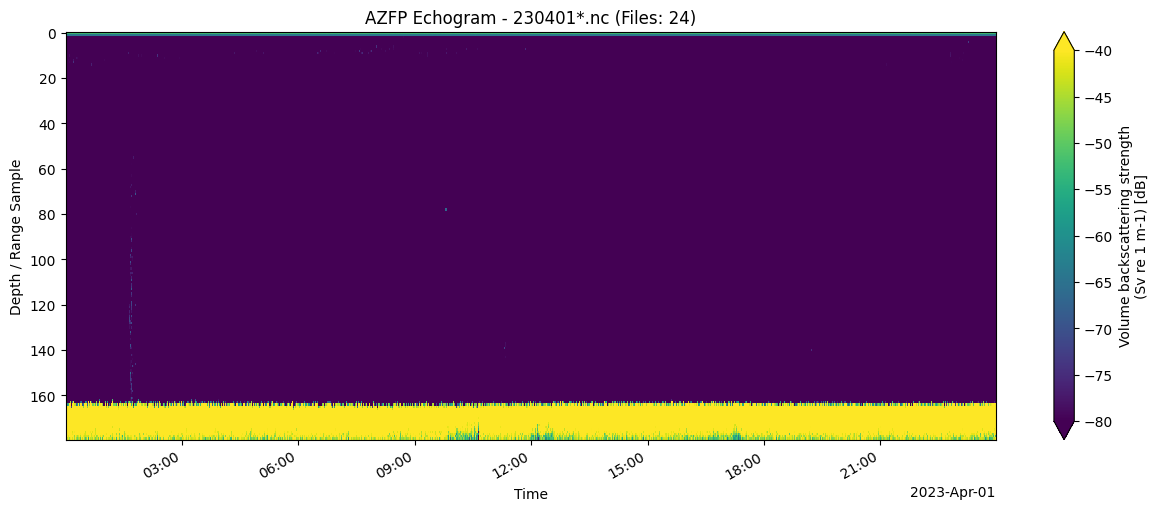

In [ ]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os

# --- USER CONFIGURATION ---
# Define the path to your folder containing the .nc files
data_dir = 'data_processed/202304_nc'  # Change this to your actual directory path

# Define your pattern here. 
# - For Daily (e.g., April 10, 2023): Use "230410*.nc"
# - For Monthly (e.g., April 2023):   Use "2304*.nc"
file_pattern = "230401*.nc" 

# --------------------------

# 1. Generate the file list automatically
search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path)) # 'sorted' ensures chronological order

print(f"Found {len(file_list)} files matching pattern: {file_pattern}")

if not file_list:
    print("No files found. Please check your directory and pattern.")
else:
    # 2. Define environment parameters
    env_params = {
        'temperature': 4, 
        'salinity': 35,    
        'pressure': 10     
    }

    # 3. Loop, calibrate, and collect
    sv_datasets = []

    print("Processing files and computing Sv...")
    for file in file_list:
        try:
            # Open converted file
            ed = ep.open_converted(file)
            
            # Calibrate to get Sv
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            # Optional: Drop extra variables to save memory if processing a whole month
            # ds_Sv = ds_Sv[['Sv']] 
            
            sv_datasets.append(ds_Sv)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # 4. Concatenate
    if sv_datasets:
        print("Concatenating datasets...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')

        print("Combination complete. Total pings:", len(combined_ds.ping_time))

        
        ds_38k = combined_ds.sel(channel='55139-38-1') 

        # 6. Plot
        plt.figure(figsize=(15, 6))
        
        # Plotting Sv
        ds_38k['Sv'].plot(x='ping_time', y='range_sample', cmap='viridis', vmin=-80, vmax=-40)

        plt.gca().invert_yaxis()
        plt.title(f"AZFP Echogram - {file_pattern} (Files: {len(file_list)})")
        plt.xlabel("Time")
        plt.ylabel("Depth / Range Sample")
        
        # Formatting the x-axis to be readable
        plt.gcf().autofmt_xdate()
        
        plt.show()
    else:
        print("No datasets were successfully processed.")

###  With changed colorscale

Found 24 files matching pattern: 230401*.nc
Processing files and computing Sv...
Concatenating datasets...
Combination complete. Total pings: 2160


C:\Users\tofar\AppData\Local\Temp\ipykernel_24820\3151903668.py:56: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined_ds = xr.concat(sv_datasets, dim='ping_time')


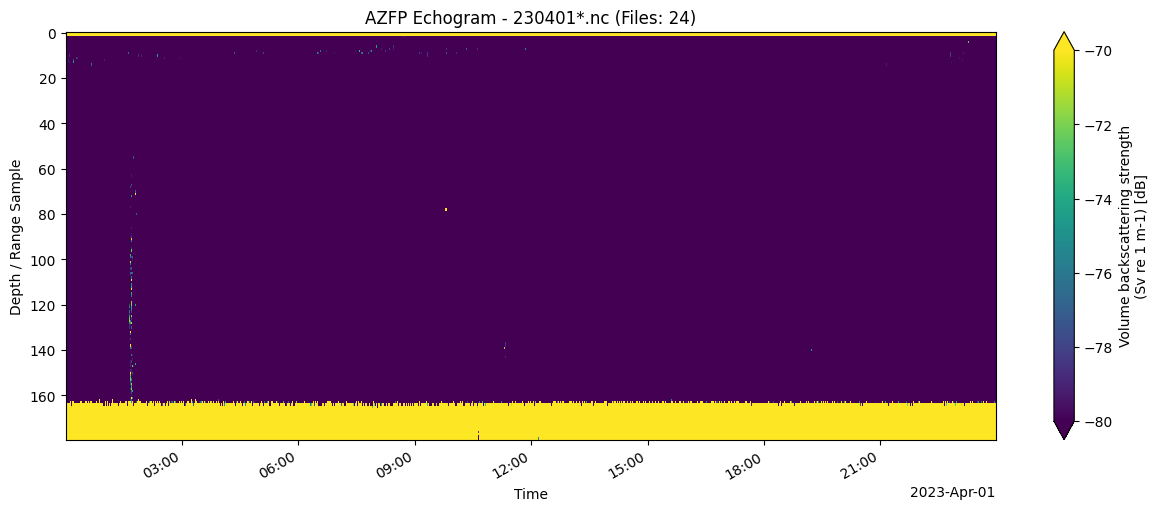

In [3]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os

# --- USER CONFIGURATION ---
# Define the path to your folder containing the .nc files
data_dir = 'data_processed/202304_nc'  # Change this to your actual directory path

# Define your pattern here. 
# - For Daily (e.g., April 10, 2023): Use "230410*.nc"
# - For Monthly (e.g., April 2023):   Use "2304*.nc"
file_pattern = "230401*.nc" 

# --------------------------

# 1. Generate the file list automatically
search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path)) # 'sorted' ensures chronological order

print(f"Found {len(file_list)} files matching pattern: {file_pattern}")

if not file_list:
    print("No files found. Please check your directory and pattern.")
else:
    # 2. Define environment parameters
    env_params = {
        'temperature': 4, 
        'salinity': 35,    
        'pressure': 10     
    }

    # 3. Loop, calibrate, and collect
    sv_datasets = []

    print("Processing files and computing Sv...")
    for file in file_list:
        try:
            # Open converted file
            ed = ep.open_converted(file)
            
            # Calibrate to get Sv
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            # Optional: Drop extra variables to save memory if processing a whole month
            # ds_Sv = ds_Sv[['Sv']] 
            
            sv_datasets.append(ds_Sv)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # 4. Concatenate
    if sv_datasets:
        print("Concatenating datasets...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')

        print("Combination complete. Total pings:", len(combined_ds.ping_time))

        
        ds_38k = combined_ds.sel(channel='55139-38-1') 

        # 6. Plot
        plt.figure(figsize=(15, 6))
        
        # Plotting Sv
        ds_38k['Sv'].plot(x='ping_time', y='range_sample', cmap='viridis', vmin=-80, vmax=-70)

        plt.gca().invert_yaxis()
        plt.title(f"AZFP Echogram - {file_pattern} (Files: {len(file_list)})")
        plt.xlabel("Time")
        plt.ylabel("Depth / Range Sample")
        
        # Formatting the x-axis to be readable
        plt.gcf().autofmt_xdate()
        
        plt.show()
    else:
        print("No datasets were successfully processed.")

### With user input for channel configuration and min/max Sv values

Found 24 files matching pattern: 230402*.nc
Processing files and computing Sv...
Concatenating datasets...
Combination complete. Total pings: 2160
Selecting the channel...

--- Available Channels ---
1: 55139-38-1
2: 55139-67-2
3: 55139-125-3
4: 55139-200-4


C:\Users\tofar\AppData\Local\Temp\ipykernel_33744\2687131670.py:56: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined_ds = xr.concat(sv_datasets, dim='ping_time')


-> Selected Channel: 55139-38-1


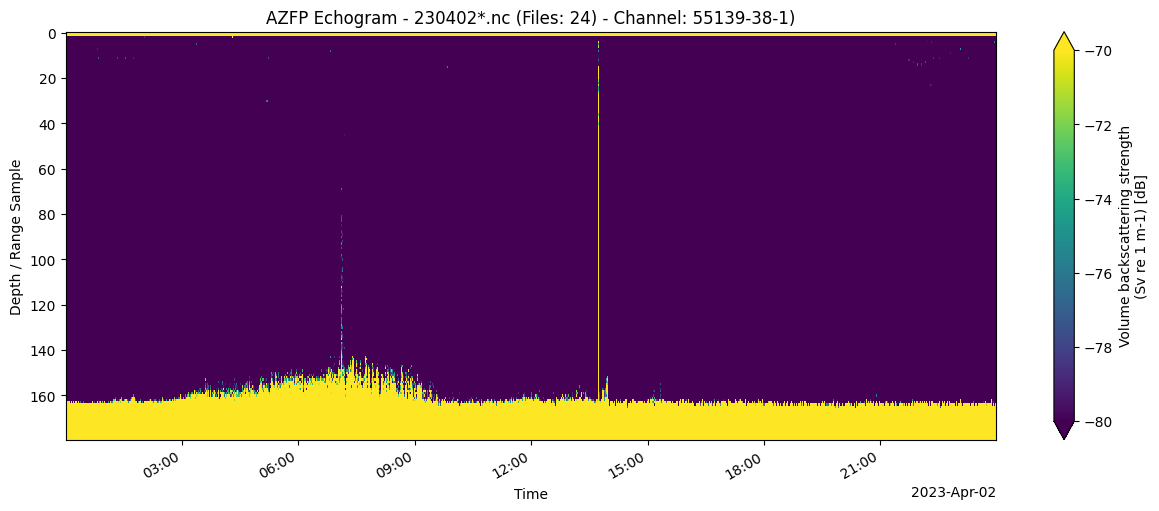

In [3]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os

# --- USER CONFIGURATION ---
# Define the path to your folder containing the .nc files
data_dir = 'data_processed/202304_nc'  # Change this to your actual directory path

# Define your pattern here. 
# - For Daily (e.g., April 10, 2023): Use "230410*.nc"
# - For Monthly (e.g., April 2023):   Use "2304*.nc"
file_pattern = "230402*.nc" 

# --------------------------

# 1. Generate the file list automatically
search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path)) # 'sorted' ensures chronological order

print(f"Found {len(file_list)} files matching pattern: {file_pattern}")

if not file_list:
    print("No files found. Please check your directory and pattern.")
else:
    # 2. Define environment parameters
    env_params = {
        'temperature': 4, 
        'salinity': 35,    
        'pressure': 10     
    }

    # 3. Loop, calibrate, and collect
    sv_datasets = []

    print("Processing files and computing Sv...")
    for file in file_list:
        try:
            # Open converted file
            ed = ep.open_converted(file)
            
            # Calibrate to get Sv
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            # Optional: Drop extra variables to save memory if processing a whole month
            # ds_Sv = ds_Sv[['Sv']] 
            
            sv_datasets.append(ds_Sv)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # 4. Concatenate
    if sv_datasets:
        print("Concatenating datasets...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')

        print("Combination complete. Total pings:", len(combined_ds.ping_time))

        print("Selecting the channel...")
        # --- Interactive Channel Selection ---

        # 1. Get the list of available channels from the dataset
        available_channels = combined_ds.channel.values

        print("\n--- Available Channels ---")
        # 2. Loop through and print them with a number (1, 2, 3...)
        for index, channel_name in enumerate(available_channels):
            print(f"{index + 1}: {channel_name}")

        # 3. Ask user for input
        try:
            user_input = int(input("Enter the number of the channel you want to plot: "))
    
            # 4. Convert user input (1-based) to list index (0-based)
            selected_index = user_input - 1
    
            # 5. Store the selected channel ID in a variable
            selected_channel_id = available_channels[selected_index]
            print(f"-> Selected Channel: {selected_channel_id}")

        except (ValueError, IndexError):
            print("Invalid selection. Defaulting to the first channel.")
            selected_channel_id = available_channels[0]

        # --- Apply Selection ---

        # 6. Use the variable to select the data
        ds_plot = combined_ds.sel(channel=selected_channel_id)

        # 6. Plot
        plt.figure(figsize=(15, 6))
        
        # Plotting Sv
        ds_plot['Sv'].plot(x='ping_time', y='range_sample', cmap='viridis', vmin=-80, vmax=-70)

        plt.gca().invert_yaxis()
        plt.title(f"AZFP Echogram - {file_pattern} (Files: {len(file_list)}) - Channel: {selected_channel_id})")
        plt.xlabel("Time")
        plt.ylabel("Depth / Range Sample")
        
        # Formatting the x-axis to be readable
        plt.gcf().autofmt_xdate()
        
        plt.show()
    else:
        print("No datasets were successfully processed.")

### With user input for time selection

Found 24 files matching pattern: 230401*.nc
Processing files and computing Sv...
Concatenating datasets...
Combination complete. Total pings: 2160
Selecting the channel...

--- Available Channels ---
1: 55139-38-1
2: 55139-67-2
3: 55139-125-3
4: 55139-200-4
-> Selected Channel: 55139-200-4


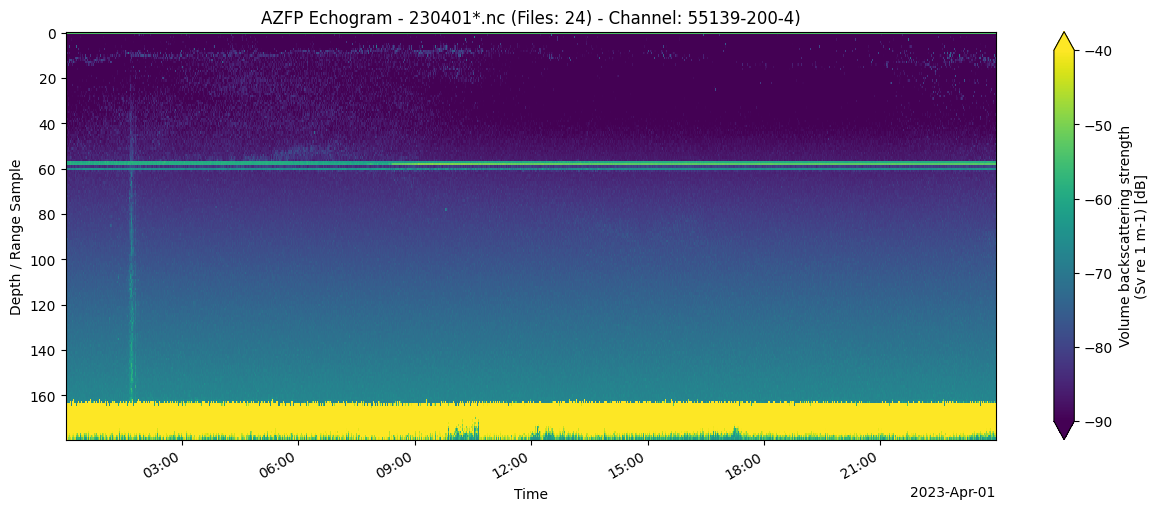

In [9]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os

# --- USER CONFIGURATION ---
# Define the path to your folder containing the .nc files
data_dir = 'data_processed/202304_nc'  # Change this to your actual directory path

# Define your pattern here. 
# - For Daily (e.g., April 10, 2023): Use "230410*.nc"
# - For Monthly (e.g., April 2023):   Use "2304*.nc"
file_pattern = input("Enter the file pattern (e.g., '230402*.nc'): ")

# --------------------------

# 1. Generate the file list automatically
search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path)) # 'sorted' ensures chronological order

print(f"Found {len(file_list)} files matching pattern: {file_pattern}")

if not file_list:
    print("No files found. Please check your directory and pattern.")
else:
    # 2. Define environment parameters
    env_params = {
        'temperature': 4, 
        'salinity': 35,    
        'pressure': 10     
    }

    # 3. Loop, calibrate, and collect
    sv_datasets = []

    print("Processing files and computing Sv...")
    for file in file_list:
        try:
            # Open converted file
            ed = ep.open_converted(file)
            
            # Calibrate to get Sv
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            # Optional: Drop extra variables to save memory if processing a whole month
            # ds_Sv = ds_Sv[['Sv']] 
            
            sv_datasets.append(ds_Sv)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # 4. Concatenate
    if sv_datasets:
        print("Concatenating datasets...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')

        print("Combination complete. Total pings:", len(combined_ds.ping_time))

        print("Selecting the channel...")
        # --- Interactive Channel Selection ---

        # 1. Get the list of available channels from the dataset
        available_channels = combined_ds.channel.values

        print("\n--- Available Channels ---")
        # 2. Loop through and print them with a number (1, 2, 3...)
        for index, channel_name in enumerate(available_channels):
            print(f"{index + 1}: {channel_name}")

        # 3. Ask user for input
        try:
            user_input = int(input("Enter the number of the channel you want to plot: "))
    
            # 4. Convert user input (1-based) to list index (0-based)
            selected_index = user_input - 1
    
            # 5. Store the selected channel ID in a variable
            selected_channel_id = available_channels[selected_index]
            print(f"-> Selected Channel: {selected_channel_id}")

        except (ValueError, IndexError):
            print("Invalid selection. Defaulting to the first channel.")
            selected_channel_id = available_channels[0]

        # --- Apply Selection ---

        # 6. Use the variable to select the data
        ds_plot = combined_ds.sel(channel=selected_channel_id)

        # 6. Plot
        plt.figure(figsize=(15, 6))
        
        # Plotting Sv
        ds_plot['Sv'].plot(x='ping_time', y='range_sample', cmap='viridis', vmin=-90, vmax=-40)

        plt.gca().invert_yaxis()
        plt.title(f"AZFP Echogram - {file_pattern} (Files: {len(file_list)}) - Channel: {selected_channel_id})")
        plt.xlabel("Time")
        plt.ylabel("Depth / Range Sample")
        
        # Formatting the x-axis to be readable
        plt.gcf().autofmt_xdate()
        
        plt.show()
    else:
        print("No datasets were successfully processed.")

### Test to see if in Y axis, the bin is being plotted instead of the depth

In [20]:
# Select the 38kHz channel
ds_38 = combined_ds.sel(channel='55139-38-1')

# Get the maximum Bin Number
max_bin = ds_38['range_sample'].max().values
print(f"Max Bin Number (Samples): {max_bin}")

# Get the maximum Calculated Range (Distance)
max_range = ds_38['echo_range'].max().values
print(f"Max Range (Meters): {max_range:.2f} m")

# Check if they are exactly the same
if max_bin == int(max_range):
    print("-> They are deceptively similar, but one is an Index, the other is Distance.")
else:
    print(f"-> They are different! (e.g. Bin {max_bin} corresponds to {max_range:.2f} meters)")

Max Bin Number (Samples): 179
Max Range (Meters): 181.17 m
-> They are different! (e.g. Bin 179 corresponds to 181.17 meters)


### Background noise removing, changing the range to true depth and inversing the Y axis

Found 72 files matching pattern: 23040[789]*.nc
Processing files...
Concatenating datasets...

--- Available Channels ---
1: 55139-38-1
2: 55139-67-2
3: 55139-125-3
4: 55139-200-4


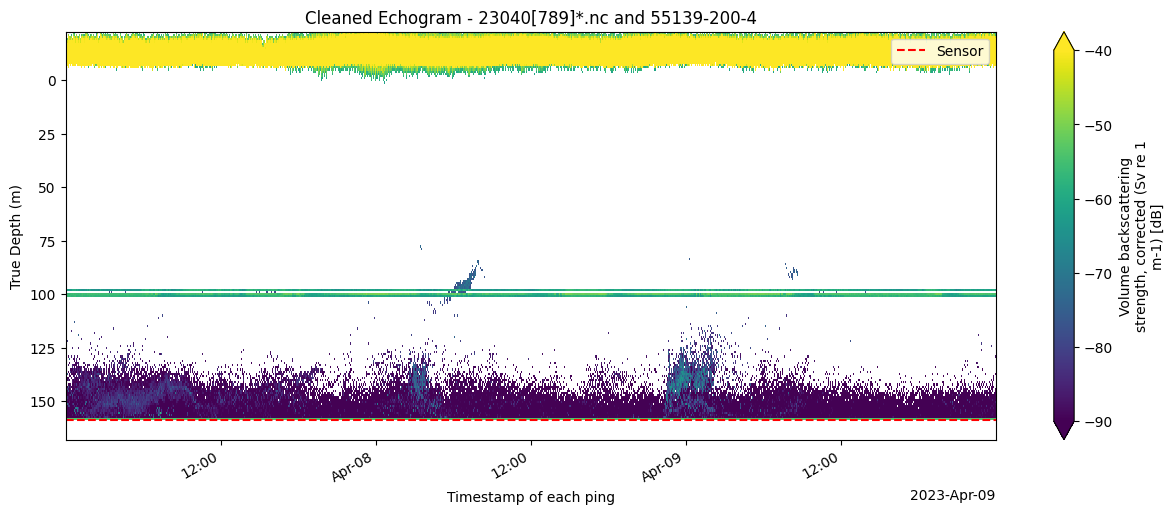

In [ ]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import warnings

# --- IMPORT FIX ---
from echopype.clean.api import remove_background_noise

warnings.filterwarnings('ignore')

# --- USER CONFIGURATION ---
data_dir = 'data_processed/202304_nc'
mooring_depth = 159  # meters
mooring_pressure = mooring_depth * 1.01  # convert to dbar approx

file_pattern = input("Enter the file pattern (e.g., '230402*.nc'): ")
# --------------------------

search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path))

print(f"Found {len(file_list)} files matching pattern: {file_pattern}")

if not file_list:
    print("No files found.")
else:
    env_params = {
        'temperature': 4, 
        'salinity': 35,    
        'pressure': 10
    }

    sv_datasets = []

    print("Processing files...")
    for file in file_list:
        try:
            ed = ep.open_converted(file)
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            # --- NOISE REMOVAL ---
            ds_clean = remove_background_noise(
                ds_Sv,
                range_sample_num=10, 
                ping_num=5,
                SNR_threshold="10" \
                "dB"
            )
            
            # --- SAFE RENAMING (The Fix) ---
            # We drop the old 'Sv' before renaming the new one to avoid conflicts
            if 'Sv_corrected' in ds_clean:
                if 'Sv' in ds_clean:
                    ds_clean = ds_clean.drop_vars(['Sv']) # Delete the noisy version
                ds_clean = ds_clean.rename({'Sv_corrected': 'Sv'}) # Rename the clean version
                
            # Keep echo_range for depth calculation
            # (Sometimes cleaning drops coords, so we ensure they are there)
            if 'echo_range' not in ds_clean.coords:
                 ds_clean = ds_clean.assign_coords(echo_range=ds_Sv.echo_range)
            
            sv_datasets.append(ds_clean)
            
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # Concatenation and Plotting
    if sv_datasets:
        print("Concatenating datasets...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')

        # --- Channel Selection ---
        available_channels = combined_ds.channel.values
        print("\n--- Available Channels ---")
        for index, channel_name in enumerate(available_channels):
            print(f"{index + 1}: {channel_name}")

        try:
            sel = int(input("Select Channel Number: ")) - 1
            selected_channel_id = available_channels[sel]
        except:
            selected_channel_id = available_channels[0]

        # --- Plotting ---
# --- Plotting ---
        ds_plot = combined_ds.sel(channel=selected_channel_id)
        
        # FIX: Use .assign_coords() instead of standard assignment
        # This forces 'depth' to become a valid axis for plotting
        true_depth = mooring_depth - ds_plot['echo_range']
        ds_plot = ds_plot.assign_coords(depth=true_depth)

        plt.figure(figsize=(15, 6))
        
        # Now 'depth' exists as a coordinate, so this will work
        ds_plot['Sv'].plot(
            x='ping_time', 
            y='depth', 
            cmap='viridis', 
            vmin=-90, 
            vmax=-40
        )
        
        plt.gca().invert_yaxis()
        plt.title(f"Cleaned Echogram - {file_pattern} and {selected_channel_id}")
        plt.ylabel("True Depth (m)")
        
        # Add sensor line
        plt.axhline(y=mooring_depth, color='red', linestyle='--', label='Sensor')
        
        plt.gcf().autofmt_xdate()
        plt.legend()
        plt.show()
    else:
        print("No datasets processed.")

In [27]:
import echopype as ep
import inspect

print(f"Echopype Version: {ep.__version__}")
print("-" * 40)

# 1. Try to import the clean module
try:
    from echopype import clean
    print("SUCCESS: Found 'echopype.clean' module.")
    
    # 2. List everything inside it
    attributes = dir(clean)
    print("\n--- Contents of echopype.clean ---")
    found = False
    for attr in attributes:
        if "noise" in attr.lower():
            print(f" -> FOUND CANDIDATE: {attr}")
            found = True
        elif not attr.startswith("_"): # Print other public attributes just in case
            print(f"    {attr}")
            
    if not found:
        print(" -> WARNING: No function with 'noise' in its name found directly in .clean")

    # 3. Check for hidden 'api' folder
    if 'api' in attributes:
        print("\n--- Contents of echopype.clean.api ---")
        from echopype.clean import api
        api_attrs = dir(api)
        for attr in api_attrs:
            if "noise" in attr.lower():
                print(f" -> FOUND CANDIDATE: {attr}")
    
except ImportError as e:
    print(f"CRITICAL: Could not even import echopype.clean: {e}")
    # Fallback: Check if it moved to a root level
    print("\nChecking root level echopype for noise functions...")
    for attr in dir(ep):
        if "noise" in attr.lower():
            print(f" -> FOUND AT ROOT: ep.{attr}")

Echopype Version: 0.1.dev2627+gebe1d44.d20251120
----------------------------------------
SUCCESS: Found 'echopype.clean' module.

--- Contents of echopype.clean ---
    api
    detect_transient
 -> FOUND CANDIDATE: estimate_background_noise
    mask_attenuated_signal
 -> FOUND CANDIDATE: mask_impulse_noise
 -> FOUND CANDIDATE: mask_transient_noise
 -> FOUND CANDIDATE: remove_background_noise
 -> FOUND CANDIDATE: transient_noise
    utils

--- Contents of echopype.clean.api ---
 -> FOUND CANDIDATE: add_remove_background_noise_attrs
 -> FOUND CANDIDATE: echopy_impulse_noise_mask
 -> FOUND CANDIDATE: estimate_background_noise
 -> FOUND CANDIDATE: mask_impulse_noise
 -> FOUND CANDIDATE: mask_transient_noise
 -> FOUND CANDIDATE: remove_background_noise
 -> FOUND CANDIDATE: transient_noise_fielding
 -> FOUND CANDIDATE: transient_noise_matecho


### Removing the lines and cleaning noise later

Found 24 files...
Concatenating...

--- Available Channels ---
1: 55139-38-1
2: 55139-67-2
3: 55139-125-3
4: 55139-200-4
Plotting Channel: 55139-38-1


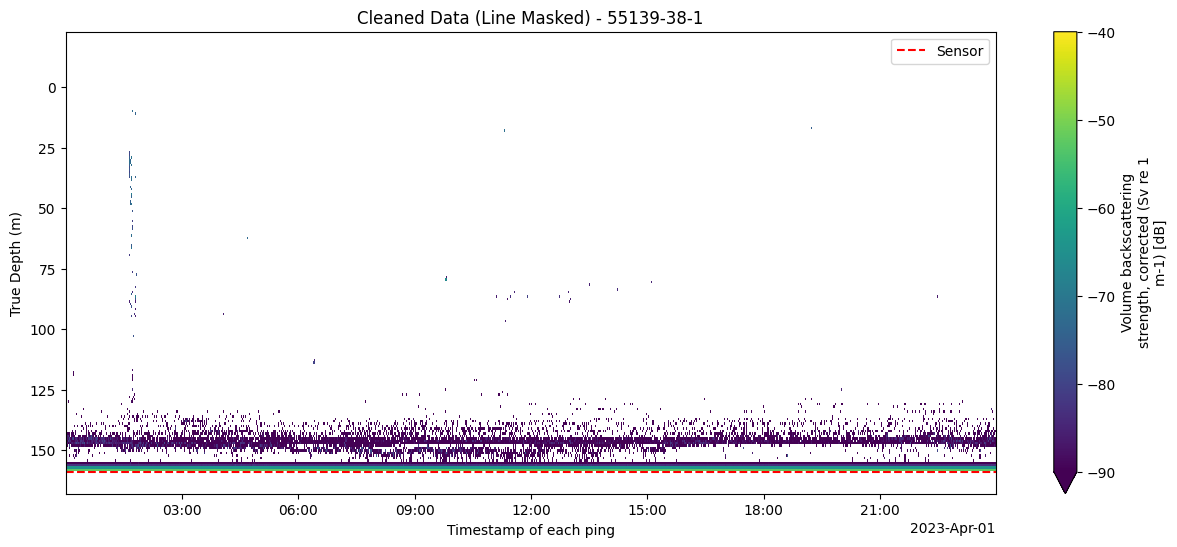

In [28]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import warnings
import numpy as np
from echopype.clean.api import remove_background_noise

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
data_dir = 'data_processed/202304_nc'
mooring_depth = 159 
mooring_pressure = mooring_depth * 1.01
bad_line_min = 97 
bad_line_max = 102
current_snr = "10dB" 

file_pattern = input("Enter the file pattern (e.g., '230402*.nc'): ")
search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path))

print(f"Found {len(file_list)} files...")

if not file_list:
    print("No files found.")
else:
    env_params = {'temperature': 4, 'salinity': 35, 'pressure': mooring_pressure}
    sv_datasets = []

    for file in file_list:
        try:
            ed = ep.open_converted(file)
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            # --- FIX: ROBUST ECHO_RANGE EXTRACTION ---
            if 'echo_range' not in ds_Sv.coords:
                if 'echo_range' in ds_Sv.data_vars:
                    ds_Sv = ds_Sv.assign_coords(echo_range=ds_Sv.data_vars['echo_range'])
                else:
                    print(f"CRITICAL: 'echo_range' not found in {os.path.basename(file)}")
                    continue

            # --- STEP 1: CALCULATE DEPTH ---
            true_depth = mooring_depth - ds_Sv.coords['echo_range']
            ds_Sv = ds_Sv.assign_coords(depth=true_depth)

            # --- STEP 2: MASK LINES (The "NaN" Step) ---
            # Deleting the lines BEFORE noise removal
            mask_good = (ds_Sv['depth'] < bad_line_min) | (ds_Sv['depth'] > bad_line_max)
            ds_Sv['Sv'] = ds_Sv['Sv'].where(mask_good)
            
            # Mask Surface (Optional)
            ds_Sv['Sv'] = ds_Sv['Sv'].where(ds_Sv['depth'] > 5)

            # --- STEP 3: REMOVE NOISE ---
            ds_clean = remove_background_noise(
                ds_Sv,
                range_sample_num=5, 
                ping_num=3,
                SNR_threshold=current_snr
            )
            
            # --- CLEANUP ---
            if 'Sv_corrected' in ds_clean:
                if 'Sv' in ds_clean: ds_clean = ds_clean.drop_vars(['Sv'])
                ds_clean = ds_clean.rename({'Sv_corrected': 'Sv'})
            elif 'Sv_clean' in ds_clean:
                if 'Sv' in ds_clean: ds_clean = ds_clean.drop_vars(['Sv'])
                ds_clean = ds_clean.rename({'Sv_clean': 'Sv'})

            if 'depth' not in ds_clean.coords:
                 ds_clean = ds_clean.assign_coords(depth=ds_Sv.coords['depth'])
            
            sv_datasets.append(ds_clean)
            
        except Exception as e:
            print(f"Error on {os.path.basename(file)}: {e}")

    # --- INTERACTIVE SELECTION & PLOTTING ---
    if sv_datasets:
        print("Concatenating...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')
        
        # 1. Show Available Channels
        available_channels = combined_ds.channel.values
        print("\n--- Available Channels ---")
        for index, channel_name in enumerate(available_channels):
            print(f"{index + 1}: {channel_name}")

        # 2. Ask User to Select
        try:
            sel = int(input("Select Channel Number: ")) - 1
            selected_channel_id = available_channels[sel]
            print(f"Plotting Channel: {selected_channel_id}")
        except:
            print("Invalid selection. Defaulting to first channel.")
            selected_channel_id = available_channels[0]

        ds_plot = combined_ds.sel(channel=selected_channel_id)
        plt.figure(figsize=(15, 6))
        ds_plot['Sv'].plot(x='ping_time', y='depth', cmap='viridis', vmin=-90, vmax=-40)
        plt.gca().invert_yaxis()
        plt.title(f"Cleaned Data (Line Masked) - {selected_channel_id}")
        plt.ylabel("True Depth (m)")
        plt.axhline(y=mooring_depth, color='red', linestyle='--', label='Sensor')
        plt.legend()
        plt.show()
    else:
        print("No valid data processed.")

### Keep the noise but prepare y axis and dlt the line

Found 24 files matching pattern: 180712*
Processing files and computing Sv...
Concatenating datasets...
Combination complete. Total pings: 2880
Selecting the channel...

--- Available Channels ---
1: 55139-38-1
2: 55139-67-2
3: 55139-125-3
4: 55139-200-4
-> Selected Channel: 55139-38-1
Calculating True Depth and removing interference lines...


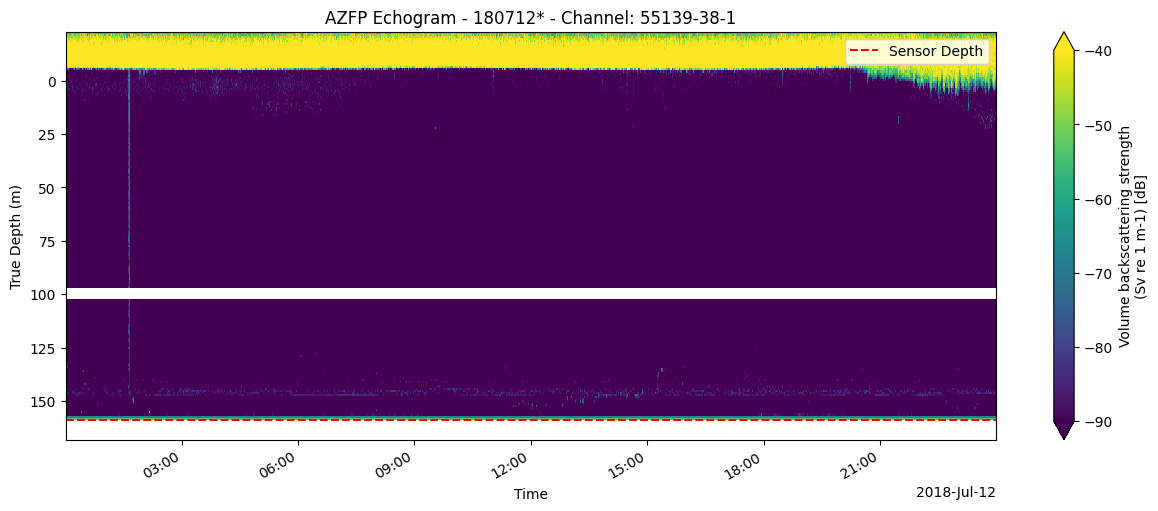

In [4]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import warnings

# Use specific warnings filter to keep output clean
warnings.filterwarnings('ignore')

# --- USER CONFIGURATION ---
# Define the path to your folder containing the .nc files
data_dir = 'data_processed/2nd Deployment_ 55139_nc'  # Change this to your actual directory path
mooring_depth = 159 
mooring_pressure = mooring_depth * 1.01
bad_line_min = 97 
bad_line_max = 102

# Define your pattern here. 
file_pattern = input("Enter the file pattern (e.g., '230402*.nc'): ")

# --------------------------

# 1. Generate the file list automatically
search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path)) # 'sorted' ensures chronological order

print(f"Found {len(file_list)} files matching pattern: {file_pattern}")

if not file_list:
    print("No files found. Please check your directory and pattern.")
else:
    # 2. Define environment parameters
    env_params = {
        'temperature': 4, 
        'salinity': 35,    
        'pressure': mooring_pressure     
    }

    # 3. Loop, calibrate, and collect
    sv_datasets = []

    print("Processing files and computing Sv...")
    for file in file_list:
        try:
            # Open converted file
            ed = ep.open_converted(file)
            
            # Calibrate to get Sv
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            sv_datasets.append(ds_Sv)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # 4. Concatenate
    if sv_datasets:
        print("Concatenating datasets...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')

        print("Combination complete. Total pings:", len(combined_ds.ping_time))

        print("Selecting the channel...")
        # --- Interactive Channel Selection ---

        # 1. Get the list of available channels from the dataset
        available_channels = combined_ds.channel.values

        print("\n--- Available Channels ---")
        # 2. Loop through and print them with a number (1, 2, 3...)
        for index, channel_name in enumerate(available_channels):
            print(f"{index + 1}: {channel_name}")

        # 3. Ask user for input
        try:
            user_input = int(input("Enter the number of the channel you want to plot: "))
    
            # 4. Convert user input (1-based) to list index (0-based)
            selected_index = user_input - 1
    
            # 5. Store the selected channel ID in a variable
            selected_channel_id = available_channels[selected_index]
            print(f"-> Selected Channel: {selected_channel_id}")

        except (ValueError, IndexError):
            print("Invalid selection. Defaulting to the first channel.")
            selected_channel_id = available_channels[0]

        # --- Apply Selection ---

        # 6. Use the variable to select the data
        ds_plot = combined_ds.sel(channel=selected_channel_id)

        # --- NEW STEP: Calculate True Depth & Mask Lines ---
        print("Calculating True Depth and removing interference lines...")

        # A. Calculate Depth: Mooring Depth - Range
        # We assign it as a coordinate so we can plot against it
        if 'echo_range' in ds_plot:
             true_depth = mooring_depth - ds_plot['echo_range']
             ds_plot = ds_plot.assign_coords(depth=true_depth)
        else:
             # Fallback just in case, though compute_Sv usually provides it
             print("Warning: 'echo_range' missing. Plotting might fail.")

        # B. Remove Instrumental Lines (97m - 102m)
        # Logic: Keep data where depth is LESS than 97 OR GREATER than 102
        mask_good_data = (ds_plot['depth'] < bad_line_min) | (ds_plot['depth'] > bad_line_max)
        ds_plot['Sv'] = ds_plot['Sv'].where(mask_good_data)

        # ---------------------------------------------------

        # 6. Plot
        plt.figure(figsize=(15, 6))
        
        # Plotting Sv against 'depth' instead of 'range_sample'
        ds_plot['Sv'].plot(
            x='ping_time', 
            y='depth',       # <--- Changed to depth
            cmap='viridis', 
            vmin=-90, 
            vmax=-40
        )

        # Invert Y-axis: 
        # Since Depth 0 is Surface and Depth 159 is Sensor,
        # Inverting puts 0 (Surface) at the Top.
        plt.gca().invert_yaxis()
        
        plt.title(f"AZFP Echogram - {file_pattern} - Channel: {selected_channel_id}")
        plt.xlabel("Time")
        plt.ylabel("True Depth (m)") # Updated Label
        
        # Add a reference line for the sensor
        plt.axhline(y=mooring_depth, color='red', linestyle='--', label='Sensor Depth')
        plt.legend()

        # Formatting the x-axis to be readable
        plt.gcf().autofmt_xdate()
        
        plt.show()
    else:
        print("No datasets were successfully processed.")

## Validation

Found 24 files matching pattern: 230412*.nc
Processing files and computing Sv...
Concatenating datasets...
Combination complete. Total pings: 2161
Selecting the channel...

--- Available Channels ---
1: 55139-38-1
2: 55139-67-2
3: 55139-125-3
4: 55139-200-4
-> Selected Channel: 55139-38-1
Calculating True Depth and removing interference lines...


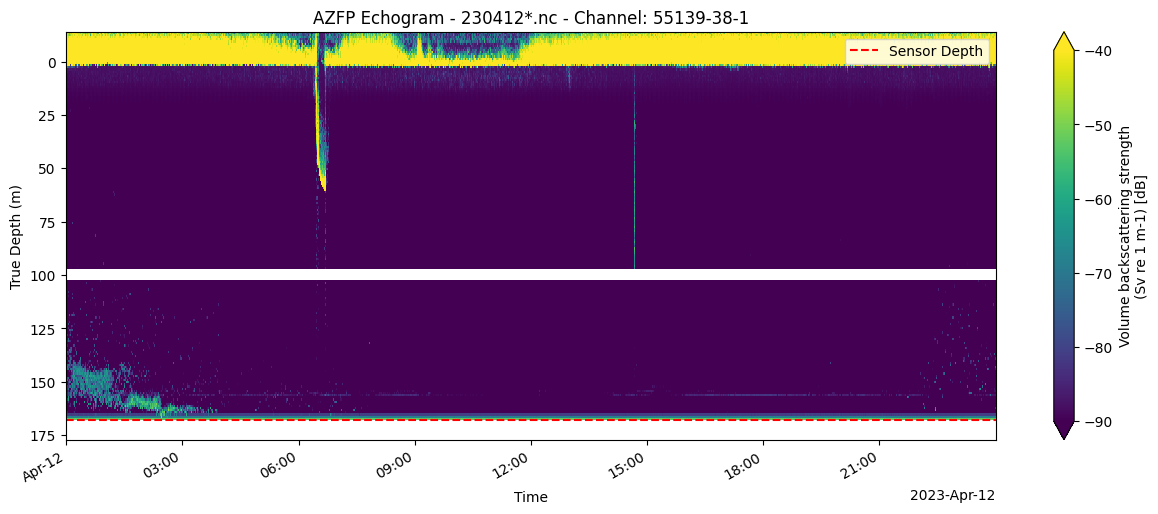

In [2]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import warnings

# Use specific warnings filter to keep output clean
warnings.filterwarnings('ignore')

# --- USER CONFIGURATION ---
# Define the path to your folder containing the .nc files
data_dir = 'data_processed/202304_nc'  # Change this to your actual directory path
mooring_depth = 168 
mooring_pressure = mooring_depth * 1.01
bad_line_min = 97 
bad_line_max = 102

# Define your pattern here. 
file_pattern = input("Enter the file pattern (e.g., '230402*.nc'): ")

# --------------------------

# 1. Generate the file list automatically
search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path)) # 'sorted' ensures chronological order

print(f"Found {len(file_list)} files matching pattern: {file_pattern}")

if not file_list:
    print("No files found. Please check your directory and pattern.")
else:
    # 2. Define environment parameters
    env_params = {
        'temperature': 4, 
        'salinity': 35,    
        'pressure': mooring_pressure     
    }

    # 3. Loop, calibrate, and collect
    sv_datasets = []

    print("Processing files and computing Sv...")
    for file in file_list:
        try:
            # Open converted file
            ed = ep.open_converted(file)
            
            # Calibrate to get Sv
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            sv_datasets.append(ds_Sv)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # 4. Concatenate
    if sv_datasets:
        print("Concatenating datasets...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')

        print("Combination complete. Total pings:", len(combined_ds.ping_time))

        print("Selecting the channel...")
        # --- Interactive Channel Selection ---

        # 1. Get the list of available channels from the dataset
        available_channels = combined_ds.channel.values

        print("\n--- Available Channels ---")
        # 2. Loop through and print them with a number (1, 2, 3...)
        for index, channel_name in enumerate(available_channels):
            print(f"{index + 1}: {channel_name}")

        # 3. Ask user for input
        try:
            user_input = int(input("Enter the number of the channel you want to plot: "))
    
            # 4. Convert user input (1-based) to list index (0-based)
            selected_index = user_input - 1
    
            # 5. Store the selected channel ID in a variable
            selected_channel_id = available_channels[selected_index]
            print(f"-> Selected Channel: {selected_channel_id}")

        except (ValueError, IndexError):
            print("Invalid selection. Defaulting to the first channel.")
            selected_channel_id = available_channels[0]

        # --- Apply Selection ---

        # 6. Use the variable to select the data
        ds_plot = combined_ds.sel(channel=selected_channel_id)

        # --- NEW STEP: Calculate True Depth & Mask Lines ---
        print("Calculating True Depth and removing interference lines...")

        # A. Calculate Depth: Mooring Depth - Range
        # We assign it as a coordinate so we can plot against it
        if 'echo_range' in ds_plot:
             true_depth = mooring_depth - ds_plot['echo_range']
             ds_plot = ds_plot.assign_coords(depth=true_depth)
        else:
             # Fallback just in case, though compute_Sv usually provides it
             print("Warning: 'echo_range' missing. Plotting might fail.")

        # B. Remove Instrumental Lines (97m - 102m)
        # Logic: Keep data where depth is LESS than 97 OR GREATER than 102
        mask_good_data = (ds_plot['depth'] < bad_line_min) | (ds_plot['depth'] > bad_line_max)
        ds_plot['Sv'] = ds_plot['Sv'].where(mask_good_data)

        # ---------------------------------------------------

        # 6. Plot
        plt.figure(figsize=(15, 6))
        
        # Plotting Sv against 'depth' instead of 'range_sample'
        ds_plot['Sv'].plot(
            x='ping_time', 
            y='depth',       # <--- Changed to depth
            cmap='viridis', 
            vmin=-90, 
            vmax=-40
        )

        # Invert Y-axis: 
        # Since Depth 0 is Surface and Depth 159 is Sensor,
        # Inverting puts 0 (Surface) at the Top.
        plt.gca().invert_yaxis()
        
        plt.title(f"AZFP Echogram - {file_pattern} - Channel: {selected_channel_id}")
        plt.xlabel("Time")
        plt.ylabel("True Depth (m)") # Updated Label
        
        # Add a reference line for the sensor
        plt.axhline(y=mooring_depth, color='red', linestyle='--', label='Sensor Depth')
        plt.legend()

        # Formatting the x-axis to be readable
        plt.gcf().autofmt_xdate()
        
        plt.show()
    else:
        print("No datasets were successfully processed.")

### Same for 55140

Found 24 files matching pattern: 230717*.nc
Processing files and computing Sv...
Concatenating datasets...
Combination complete. Total pings: 2880
Selecting the channel...

--- Available Channels ---
1: 55140-200-1
2: 55140-333-2
3: 55140-455-3
-> Selected Channel: 55140-455-3
Calculating True Depth and removing interference lines...


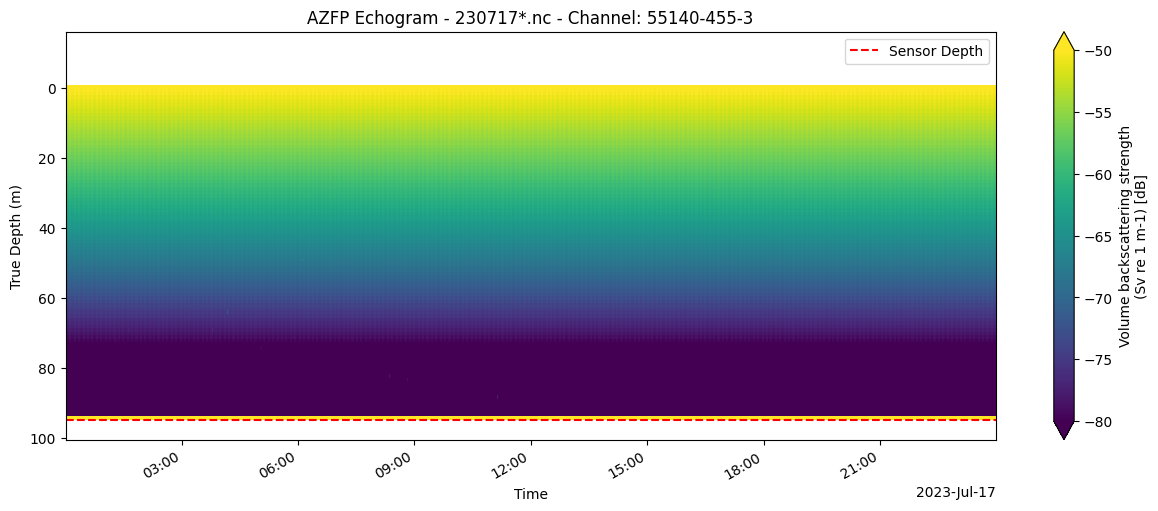

In [29]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import warnings

# Use specific warnings filter to keep output clean
warnings.filterwarnings('ignore')

# --- USER CONFIGURATION ---
# Define the path to your folder containing the .nc files
data_dir = 'data_processed/july_half_nc'  # Change this to your actual directory path
mooring_depth = 95 
mooring_pressure = mooring_depth * 1.01


# Define your pattern here. 
file_pattern = input("Enter the file pattern (e.g., '230402*.nc'): ")

# --------------------------

# 1. Generate the file list automatically
search_path = os.path.join(data_dir, file_pattern)
file_list = sorted(glob.glob(search_path)) # 'sorted' ensures chronological order

print(f"Found {len(file_list)} files matching pattern: {file_pattern}")

if not file_list:
    print("No files found. Please check your directory and pattern.")
else:
    # 2. Define environment parameters
    env_params = {
        'temperature': 4, 
        'salinity': 35,    
        'pressure': mooring_pressure     
    }

    # 3. Loop, calibrate, and collect
    sv_datasets = []

    print("Processing files and computing Sv...")
    for file in file_list:
        try:
            # Open converted file
            ed = ep.open_converted(file)
            
            # Calibrate to get Sv
            ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)
            
            sv_datasets.append(ds_Sv)
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # 4. Concatenate
    if sv_datasets:
        print("Concatenating datasets...")
        combined_ds = xr.concat(sv_datasets, dim='ping_time')

        print("Combination complete. Total pings:", len(combined_ds.ping_time))

        print("Selecting the channel...")
        # --- Interactive Channel Selection ---

        # 1. Get the list of available channels from the dataset
        available_channels = combined_ds.channel.values

        print("\n--- Available Channels ---")
        # 2. Loop through and print them with a number (1, 2, 3...)
        for index, channel_name in enumerate(available_channels):
            print(f"{index + 1}: {channel_name}")

        # 3. Ask user for input
        try:
            user_input = int(input("Enter the number of the channel you want to plot: "))
    
            # 4. Convert user input (1-based) to list index (0-based)
            selected_index = user_input - 1
    
            # 5. Store the selected channel ID in a variable
            selected_channel_id = available_channels[selected_index]
            print(f"-> Selected Channel: {selected_channel_id}")

        except (ValueError, IndexError):
            print("Invalid selection. Defaulting to the first channel.")
            selected_channel_id = available_channels[0]

        # --- Apply Selection ---

        # 6. Use the variable to select the data
        ds_plot = combined_ds.sel(channel=selected_channel_id)

        # --- NEW STEP: Calculate True Depth & Mask Lines ---
        print("Calculating True Depth and removing interference lines...")

        # A. Calculate Depth: Mooring Depth - Range
        # We assign it as a coordinate so we can plot against it
        if 'echo_range' in ds_plot:
             true_depth = mooring_depth - ds_plot['echo_range']
             ds_plot = ds_plot.assign_coords(depth=true_depth)
        else:
             # Fallback just in case, though compute_Sv usually provides it
             print("Warning: 'echo_range' missing. Plotting might fail.")

        # B. Remove Instrumental Lines (97m - 102m)
        # Logic: Keep data where depth is LESS than 97 OR GREATER than 102
        mask_good_data = (ds_plot['depth'] > -1)
        ds_plot['Sv'] = ds_plot['Sv'].where(mask_good_data)

        # ---------------------------------------------------

        # 6. Plot
        plt.figure(figsize=(15, 6))
        
        # Plotting Sv against 'depth' instead of 'range_sample'
        ds_plot['Sv'].plot(
            x='ping_time', 
            y='depth',       # <--- Changed to depth
            cmap='viridis', 
            vmin=-80, 
            vmax=-50
        )

        # Invert Y-axis: 
        # Since Depth 0 is Surface and Depth 159 is Sensor,
        # Inverting puts 0 (Surface) at the Top.
        plt.gca().invert_yaxis()
        
        plt.title(f"AZFP Echogram - {file_pattern} - Channel: {selected_channel_id}")
        plt.xlabel("Time")
        plt.ylabel("True Depth (m)") # Updated Label
        
        # Add a reference line for the sensor
        plt.axhline(y=mooring_depth, color='red', linestyle='--', label='Sensor Depth')
        plt.legend()

        # Formatting the x-axis to be readable
        plt.gcf().autofmt_xdate()
        
        plt.show()
    else:
        print("No datasets were successfully processed.")